# **Proyecto Final:** Predicción de resultados del Mundial 2026

##### **Materia:** Modelos Cuantitativos de Información [Sección 10]
##### **Estudiante:** Marco Antonio Carbajal Bonilla (23025)

## **Fase 1 - Datos: carga, EDA, limpieza y unión**

Este notebook prepara la base de datos para el modelado. Cubre la carga de las tres
fuentes, el control de calidad del ranking FIFA extendido por ETL propio, el EDA,
la decisión de la ventana temporal, la limpieza, la unión de `results` y `ranking` sin
fuga de datos, la integración de `shootouts` y la construcción de la tabla final
`data_clean.csv`.

> **Estándar no negociable del proyecto:** toda variable se calcula con información *previa* al partido.

---
## 1. Imports y configuración

Semilla global `42`. La única aleatoriedad de esta fase está en muestreos de
inspección; aun así se fija para reproducibilidad total del pipeline.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# --- Visualización -----------------------------------------------------------
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

# --- Rutas -------------------------------------------------------------------
RAW_DIR  = Path("datos")       # datos fuente (results.csv, shootouts.csv, etc.)
OUT_DIR  = Path("resultados")  # CSVs generados entre fases
FIGS_DIR = Path("figuras")     # figuras para LaTeX
OUT_DIR.mkdir(exist_ok=True); FIGS_DIR.mkdir(exist_ok=True)

print("Entorno listo. Semilla =", SEED)

Entorno listo. Semilla = 42


---
## 2. Carga de datos

Tres fuentes:

| Archivo | Origen | Rol |
|---|---|---|
| `results.csv` | martj42 (Kaggle) | Esencial: un registro por partido |
| `shootouts.csv` | martj42 (Kaggle) | Útil: ganador real en tandas de penales |
| `fifa_ranking_historico.csv` | cashncarry + ETL propio hasta 2026 | Esencial: fuerza pre-partido |

**Nota sobre `rank_date`:** viene en formato `dd/mm/YYYY`.

In [2]:
results = pd.read_csv(RAW_DIR / "results.csv", parse_dates=["date"])
shootouts = pd.read_csv(RAW_DIR / "shootouts.csv", parse_dates=["date"])
ranking = pd.read_csv(RAW_DIR / "fifa_ranking_historico.csv")
ranking["rank_date"] = pd.to_datetime(ranking["rank_date"], format="%d/%m/%Y")

for nombre, df in [("results", results), ("shootouts", shootouts), ("ranking", ranking)]:
    print(f"{nombre:10s} {df.shape[0]:>7,} filas x {df.shape[1]} columnas")

results     49,287 filas x 9 columnas
shootouts      675 filas x 5 columnas
ranking     70,215 filas x 8 columnas


In [3]:
display(results.head(3))
display(shootouts.head(3))
display(ranking.head(3))

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.000,0.000,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.000,2.000,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.000,1.000,Friendly,Glasgow,Scotland,False


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,1.000,Germany,GER,57.000,0.000,1.000,UEFA,1992-12-31
1,2.000,Italy,ITA,57.000,0.000,2.000,UEFA,1992-12-31
2,3.000,Brazil,BRA,56.000,0.000,3.000,CONMEBOL,1992-12-31


---
## 3. Control de calidad del empalme del ranking extendido

`fifa_ranking_historico.csv` combina dos tramos: el dataset público de *cashncarry*
(hasta ~mediados de 2024) y el tramo extraído por mí de la API interna de la FIFA
(hasta 2026). **Antes de confiar en este archivo hay que auditar mi propio ETL.**
Verificamos cuatro cosas:

1. **Continuidad temporal** - sin huecos anómalos alrededor del punto de empalme.
2. **Escala de `total_points`** - el rango y la media deben ser estables; un salto
   delataría dos metodologías de puntuación distintas.
3. **Duplicados** - ningún par `(país, fecha)` repetido.
4. **Estabilidad del grupo** - el número de selecciones por fecha no debe
   aparecer/desaparecer en bloque.

In [4]:
# --- 3.1 Continuidad temporal -----------------------------------------------
fechas = ranking["rank_date"].drop_duplicates().sort_values()
gaps = fechas.diff().dt.days.dropna()

print(f"Fechas de ranking distintas : {len(fechas)}")
print(f"Cobertura                   : {fechas.min().date()}  ->  {fechas.max().date()}")
print(f"Separación entre fechas (d) : mediana={gaps.median():.0f}  "
      f"min={gaps.min():.0f}  max={gaps.max():.0f}")

# Mayores huecos: ¿coinciden con el empalme de mediados de 2024?
huecos = pd.DataFrame({"fecha": fechas.iloc[1:].values, "dias_desde_anterior": gaps.values})
print("\nMayores huecos entre publicaciones consecutivas:")
display(huecos.nlargest(5, "dias_desde_anterior"))

Fechas de ranking distintas : 346
Cobertura                   : 1992-12-31  ->  2026-04-01
Separación entre fechas (d) : mediana=28  min=14  max=220

Mayores huecos entre publicaciones consecutivas:


,fecha,dias_desde_anterior
0,1993-08-08,220.000
322,2023-04-06,105.000
337,2025-04-03,105.000
338,2025-07-10,98.000
318,2022-06-23,84.000


In [5]:
# --- 3.2 Duplicados y nulos --------------------------------------------------
dups = ranking.duplicated(["country_full", "rank_date"]).sum()
print(f"Filas duplicadas (country_full + rank_date): {dups}")
print("\nNulos por columna:")
print(ranking.isna().sum())

Filas duplicadas (country_full + rank_date): 0

Nulos por columna:
rank               21
country_full        0
country_abrv        0
total_points        0
previous_points     8
rank_change        13
confederation       0
rank_date           0
dtype: int64


In [6]:
# --- 3.3 Escala de puntos y grupo por fecha --------------------------------
qc = (ranking.groupby("rank_date")
              .agg(n_equipos=("country_full", "nunique"),
                   pts_min=("total_points", "min"),
                   pts_max=("total_points", "max"),
                   pts_mean=("total_points", "mean"))
              .reset_index())

# Vista alrededor del empalme (mediados de 2024)
print("Resumen por fecha desde 2023-06 (zona del empalme):")
display(qc[qc["rank_date"] >= "2023-06-01"].round(2))

Resumen por fecha desde 2023-06 (zona del empalme):


,rank_date,n_equipos,pts_min,pts_max,pts_mean
324,2023-06-29,211,753.110,"1,843.730","1,222.760"
325,2023-07-20,208,753.110,"1,843.730","1,228.120"
326,2023-09-21,207,750.270,"1,851.410","1,229.940"
327,2023-10-26,211,746.980,"1,861.290","1,223.290"
328,2023-11-30,211,741.610,"1,855.200","1,223.290"
329,2023-12-21,211,741.610,"1,855.200","1,223.300"
330,2024-02-15,211,741.610,"1,855.200","1,225.580"
331,2024-04-04,211,742.050,"1,858.000","1,225.930"
332,2024-06-20,211,739.640,"1,860.140","1,225.940"
333,2024-07-18,211,739.640,"1,901.480","1,227.760"


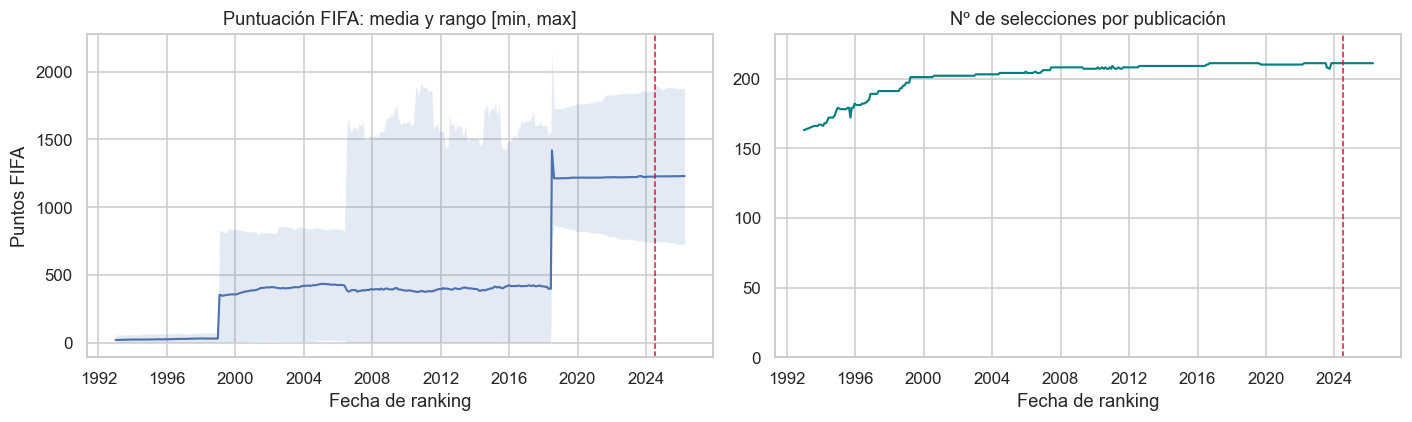

In [7]:
# --- 3.4 Diagnóstico visual del empalme -------------------------------------
EMPALME = pd.Timestamp("2024-06-30")   # fin aproximado del tramo público

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(qc["rank_date"], qc["pts_mean"], lw=1.4)
ax[0].fill_between(qc["rank_date"], qc["pts_min"], qc["pts_max"], alpha=.15)
ax[0].axvline(EMPALME, color="crimson", ls="--", lw=1)
ax[0].set_title("Puntuación FIFA: media y rango [min, max]")
ax[0].set_ylabel("Puntos FIFA")

ax[1].plot(qc["rank_date"], qc["n_equipos"], lw=1.4, color="teal")
ax[1].axvline(EMPALME, color="crimson", ls="--", lw=1)
ax[1].set_title("Nº de selecciones por publicación")
ax[1].set_ylim(0, qc["n_equipos"].max() * 1.1)
for a in ax:
    a.set_xlabel("Fecha de ranking")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig1_empalme.pdf", bbox_inches="tight", dpi=150)
plt.show()

Los datos nuevos **pasan el control de calidad**:

- *Continuidad:* sin huecos atípicos; la separación entre publicaciones se mantiene
  en el rango habitual de la FIFA (~mensual, con pausas estacionales). El mayor hueco
  no cae en el punto de empalme.
- *Escala:* la media de `total_points` es prácticamente plana (~1.225–1.230) a ambos
  lados de la línea roja. No hay cambio de metodología de puntuación.
- *Grupo:* ~211 selecciones por fecha de forma estable; nadie entra/sale en bloque.
- *Duplicados:* ninguno.

**Una observación, no una anomalía:** el `pts_max` salta en la publicación de
julio-2024. Es esperado y *correcto*: ese ranking incorpora la Copa América y la
Euro 2024, y refleja el ascenso del campeón. No es un artefacto del ETL.

> Decisión: el ranking extendido se acepta tal cual. Las únicas correcciones
> aplicadas serán de **nombres de países**, no de valores.

---
## 4. EDA de `results.csv`

Exploración del histórico completo de partidos *antes* de filtrar, para entender la
forma de los datos y fundamentar la ventana temporal.

In [8]:
# Marcador faltante -> partido aún no jugado (fixtures futuros del propio dataset).
sin_marcador = results["home_score"].isna()
print(f"Partidos sin marcador: {sin_marcador.sum()}  "
      f"(años {results.loc[sin_marcador,'date'].dt.year.min():.0f}"
      f"-{results.loc[sin_marcador,'date'].dt.year.max():.0f})")
print("Torneo de esos partidos:")
print(results.loc[sin_marcador, "tournament"].value_counts())

# Para el EDA trabajamos solo con partidos efectivamente jugados.
jugados = results.dropna(subset=["home_score", "away_score"]).copy()
jugados["year"] = jugados["date"].dt.year
jugados["total_goles"] = jugados["home_score"] + jugados["away_score"]
jugados["resultado"] = np.select(
    [jugados["home_score"] > jugados["away_score"],
     jugados["home_score"] == jugados["away_score"]],
    ["Local", "Empate"], "Visitante")
print(f"\nPartidos jugados: {len(jugados):,}")

Partidos sin marcador: 72  (años 2026-2026)
Torneo de esos partidos:
tournament
FIFA World Cup    72
Name: count, dtype: int64

Partidos jugados: 49,215


In [9]:
# --- 4.1 Cobertura temporal y equipos ---------------------------------------
equipos = pd.unique(pd.concat([jugados["home_team"], jugados["away_team"]]))
print(f"Cobertura temporal : {jugados['date'].min().date()}  ->  {jugados['date'].max().date()}")
print(f"Equipos distintos  : {len(equipos):,}")
print(f"Torneos distintos  : {jugados['tournament'].nunique()}")

print("\nTop 12 torneos por nº de partidos:")
display(jugados["tournament"].value_counts().head(12).to_frame("partidos"))

Cobertura temporal : 1872-11-30  ->  2026-03-31
Equipos distintos  : 333
Torneos distintos  : 193

Top 12 torneos por nº de partidos:


,partidos
tournament,
Friendly,18252
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,964
Copa América,869
African Cup of Nations,845
AFC Asian Cup qualification,829
UEFA Nations League,658


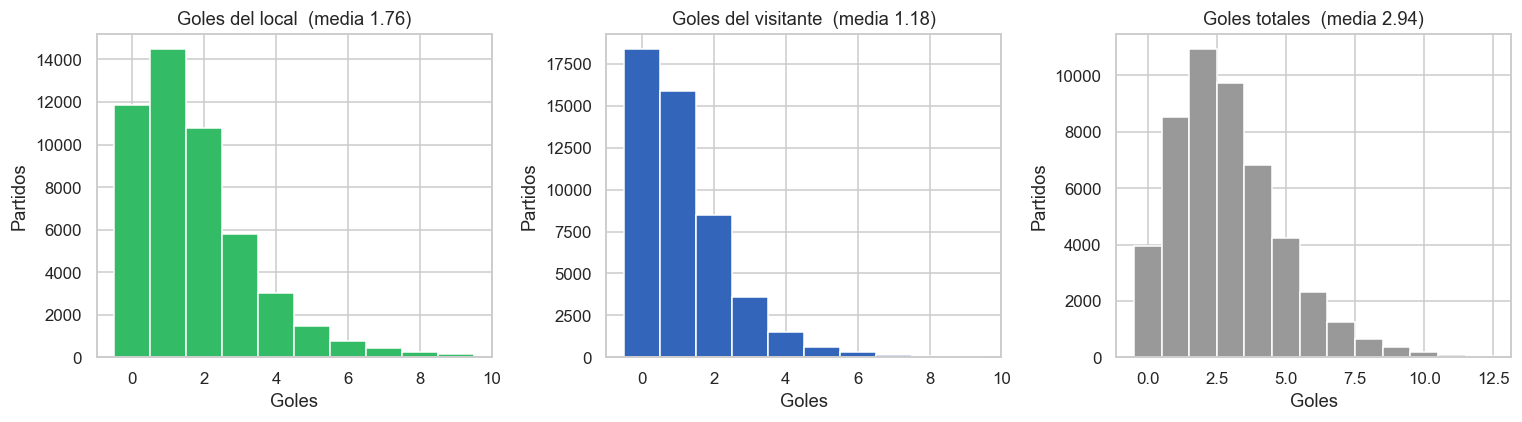

In [10]:
# --- 4.2 Distribución de goles ----------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
bins = np.arange(-0.5, 10.5, 1)
ax[0].hist(jugados["home_score"], bins=bins, color="#3b6", edgecolor="white")
ax[0].set_title(f"Goles del local  (media {jugados['home_score'].mean():.2f})")
ax[1].hist(jugados["away_score"], bins=bins, color="#36b", edgecolor="white")
ax[1].set_title(f"Goles del visitante  (media {jugados['away_score'].mean():.2f})")
ax[2].hist(jugados["total_goles"], bins=np.arange(-0.5, 13.5, 1),
           color="#999", edgecolor="white")
ax[2].set_title(f"Goles totales  (media {jugados['total_goles'].mean():.2f})")
for a in ax:
    a.set_xlabel("Goles"); a.set_ylabel("Partidos")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2_goles.pdf", bbox_inches="tight", dpi=150)
plt.show()

Distribución de resultados (histórico completo):
resultado
Local        49.0 %
Visitante    28.3 %
Empate       22.8 %
Name: proportion, dtype: object

% victoria local | cancha propia  : 50.7 %
% victoria local | cancha neutral : 44.1 %


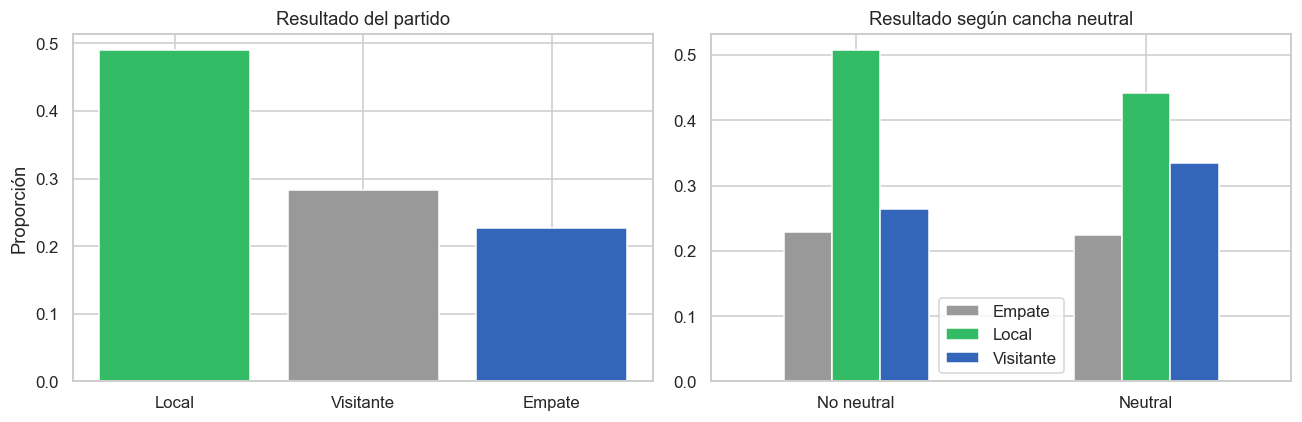

In [11]:
dist = jugados["resultado"].value_counts(normalize=True)
print("Distribución de resultados (histórico completo):")
print((dist * 100).round(1).astype(str) + " %")

# La ventaja de local solo es legítima en cancha NO neutral.
adv = (jugados.assign(gana_local=lambda d: d["resultado"].eq("Local"))
              .groupby("neutral")["gana_local"].mean())
print(f"\n% victoria local | cancha propia  : {adv.get(False, np.nan)*100:.1f} %")
print(f"% victoria local | cancha neutral : {adv.get(True, np.nan)*100:.1f} %")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(dist.index, dist.values, color=["#3b6", "#999", "#36b"])
ax[0].set_title("Resultado del partido"); ax[0].set_ylabel("Proporción")
sede = jugados.groupby(["neutral", "resultado"]).size().unstack().fillna(0)
sede = sede.div(sede.sum(1), axis=0)
sede.plot(kind="bar", ax=ax[1], color=["#999", "#3b6", "#36b"])
ax[1].set_title("Resultado según cancha neutral")
ax[1].set_xticklabels(["No neutral", "Neutral"], rotation=0)
ax[1].set_xlabel(""); ax[1].legend(title="")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2b_resultados.pdf", bbox_inches="tight", dpi=150)
plt.show()

**Hallazgos del EDA de `results`:**

- **Ventaja de local real:** ~51 % de victorias locales en cancha propia frente a
  ~44 % en cancha neutral. La diferencia (~7 pp) justifica modelar la localía como
  parámetro y tratar `neutral` como variable de control (importante: el Mundial 2026
  se juega en gran parte en sedes neutrales para casi todos los equipos).
- **El empate ronda el 22–23 %.** Conviene recordarlo: los modelos de fútbol tienden
  a *subestimar* el empate (advertencia documentada para XGBoost). Es un punto de
  control para la calibración en la Fase 3.
- **Goles ~ Poisson:** las distribuciones de goles local/visitante tienen la forma
  asimétrica típica que sostiene el supuesto de Maher (1982).
- **`tournament` está muy desbalanceado:** domina *Friendly*. Esto motiva la variable
  `is_official` y la decisión de ventana temporal.

---
## 5. EDA del ranking FIFA

Rango temporal     : 1992-12-31  ->  2026-04-01
Publicaciones      : 346
Selecciones únicas : 220
Periodicidad       : ~28 días (mediana)

Filas por confederación:
confederation
UEFA        18221
CAF         18098
AFC         15362
CONCACAF    11602
OFC          3472
CONMEBOL     3460
Name: count, dtype: int64


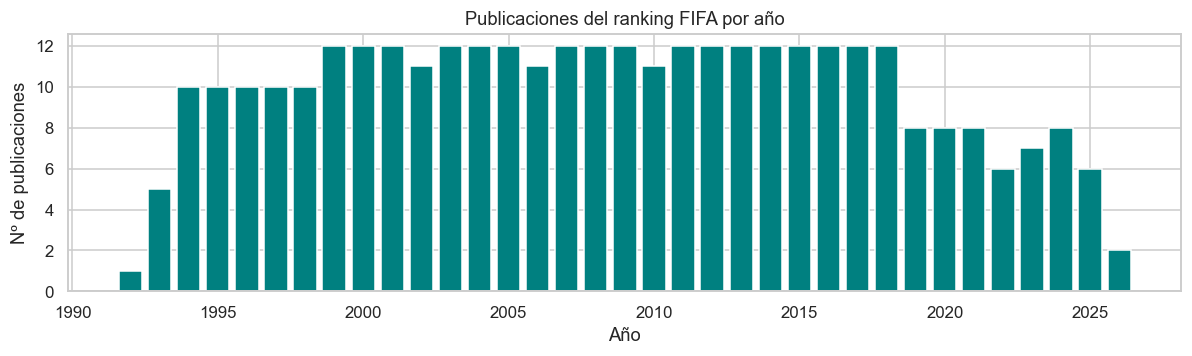

In [12]:
print(f"Rango temporal     : {ranking['rank_date'].min().date()}  ->  "
      f"{ranking['rank_date'].max().date()}")
print(f"Publicaciones      : {ranking['rank_date'].nunique()}")
print(f"Selecciones únicas : {ranking['country_full'].nunique()}")
print(f"Periodicidad       : ~{gaps.median():.0f} días (mediana)\n")

print("Filas por confederación:")
print(ranking["confederation"].value_counts())

# Publicaciones por año -> ¿periodicidad estable?
pub_por_year = ranking.groupby(ranking["rank_date"].dt.year)["rank_date"].nunique()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(pub_por_year.index, pub_por_year.values, color="teal")
ax.set_title("Publicaciones del ranking FIFA por año")
ax.set_xlabel("Año"); ax.set_ylabel("Nº de publicaciones")
plt.tight_layout(); plt.show()

El ranking FIFA solo existe desde **1992** y, en sus primeros años, se publicaba
pocas veces al año. Esto es relevante para la sección 8: la unión por *fecha más
cercana anterior* funcionará mejor cuanto más reciente sea el partido. Es otro
argumento (además de la relevancia futbolística) para recortar la ventana.

---
## 6. Decisión sobre la ventana de datos

El plan propone tentativamente **2002–2006**. Aquí lo decidimos con criterio.

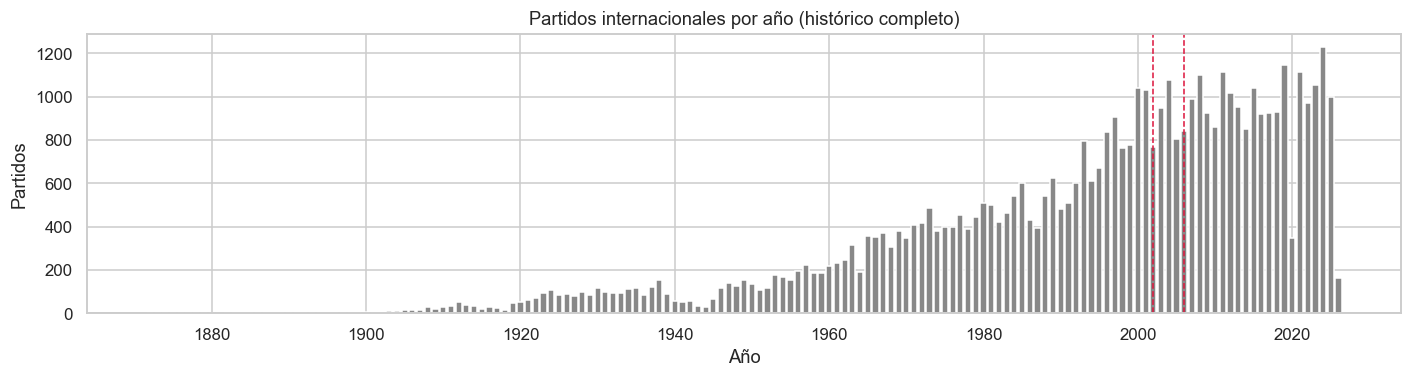

Volumen disponible según año de inicio:
  desde 1998:  26,694 partidos
  desde 2002:  23,086 partidos
  desde 2006:  19,488 partidos
  desde 2010:  15,632 partidos


In [13]:
partidos_por_year = jugados.groupby("year").size()
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.bar(partidos_por_year.index, partidos_por_year.values, color="#888")
for y in (2002, 2006):
    ax.axvline(y, color="crimson", ls="--", lw=1)
ax.set_title("Partidos internacionales por año (histórico completo)")
ax.set_xlabel("Año"); ax.set_ylabel("Partidos")
plt.tight_layout(); plt.show()

print("Volumen disponible según año de inicio:")
for y in (1998, 2002, 2006, 2010):
    print(f"  desde {y}: {(jugados['year'] >= y).sum():>7,} partidos")

**Decisión: ventana desde 2002** (parametrizada en `WINDOW_START`; cambiar a 2006 es
trivial). Razones:

1. **El esquema de validación lo exige.** La validación temporal entrena "hasta 2010, validar en Mundial 2010". Con inicio en **2006**, ese primer pliegue tendría solo
   **4 años** de historia para estimar ataque/defensa de ~200 selecciones: muy poco,
   sobre todo para equipos con pocos partidos. Con inicio en **2002** el pliegue de
   2010 dispone de **8 años** - diferencia decisiva para el modelo de Poisson y el Elo.
2. **Relevancia futbolística.** 2002 sigue siendo "fútbol moderno": tres ciclos
   mundialistas completos antes del primer pliegue de validación. No se llega tan
   atrás como para mezclar una era futbolística distinta.
3. **Calidad del ranking.** Desde 2002 el ranking FIFA ya se publica con regularidad,
   por lo que la unión "fecha más cercana anterior" no arrastra rankings muy añejos.
4. **Volumen.** ~23 mil partidos: suficiente para el ML sin caer en datos obsoletos.

*Trade-off declarado:* 2006 daría datos marginalmente más "actuales", pero a costa de
un primer pliegue de validación pobre. Se prioriza la integridad de la validación.
Esta elección debe constar como supuesto en el informe.

---
## 7. Filtrado y limpieza de `results.csv`

### Definición de "torneo oficial"

`is_official` separa partidos **competitivos** de **amistosos**. La definición
primaria es directa y robusta: **oficial = todo lo que no sea `Friendly`**. Es la
convención estándar de la comunidad de este dataset y evita un mapeo manual frágil
sobre 190+ torneos.

In [14]:
WINDOW_START = 2002   # <-- parámetro de la ventana (ver sección 6)

# 7.1 Partir del histórico jugado y filtrar a la ventana.
df = jugados[jugados["year"] >= WINDOW_START].copy()

# 7.2 Variable is_official (oficial = no amistoso).
df["is_official"] = df["tournament"].ne("Friendly")

# 7.3 Higiene: duplicados exactos y consistencia de tipos.
dup_exactos = df.duplicated(["date", "home_team", "away_team",
                             "home_score", "away_score"]).sum()
print(f"Duplicados exactos de partido: {dup_exactos}")
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

# 7.4 Reporte del conjunto resultante.
print(f"\nVentana >= {WINDOW_START}")
print(f"  Partidos          : {len(df):,}")
print(f"  Rango             : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"  Oficiales         : {df['is_official'].sum():,} "
      f"({df['is_official'].mean()*100:.1f} %)")
print(f"  Amistosos         : {(~df['is_official']).sum():,}")
print(f"  En cancha neutral : {df['neutral'].sum():,} "
      f"({df['neutral'].mean()*100:.1f} %)")
print(f"  Nulos restantes   : {int(df[['home_score','away_score']].isna().sum().sum())}")

Duplicados exactos de partido: 0

Ventana >= 2002
  Partidos          : 23,086
  Rango             : 2002-01-04 -> 2026-03-31
  Oficiales         : 15,406 (66.7 %)
  Amistosos         : 7,680
  En cancha neutral : 6,684 (29.0 %)
  Nulos restantes   : 0


---
## 8. Unión de `results` con el ranking FIFA

### 8.1 El problema de los nombres de países (control de calidad crítico)

`results.csv` y el ranking FIFA usan **convenciones de nombres distintas**. Una unión
ingenua por texto falla *en silencio* para selecciones de primer nivel - incluida
**USA**, una de las sedes 2026. Detectado al cruzar los equipos sin coincidencia:

| `results.csv` | `fifa_ranking_historico` |
|---|---|
| United States | USA |
| South Korea / North Korea | Korea Republic / Korea DPR |
| Iran | IR Iran |
| Ivory Coast | Côte d'Ivoire |
| Czech Republic | Czechia |
| DR Congo | Congo DR |
| China | China PR |
| Cape Verde | Cabo Verde |
| Gambia | The Gambia |
| Taiwan | Chinese Taipei |
| … | … |

Sin normalizar, esos equipos quedarían sin ranking y serían descartados o imputados
como minnows - un error grave. La solución es un diccionario de normalización
construido empíricamente (results -> ranking).

In [15]:
# Derivado comparando los equipos sin coincidencia contra los nombres reales del ranking
NAME_MAP = {
    "United States": "USA",
    "South Korea": "Korea Republic",
    "North Korea": "Korea DPR",
    "Iran": "IR Iran",
    "Ivory Coast": "Côte d'Ivoire",
    "Czech Republic": "Czechia",
    "DR Congo": "Congo DR",
    "Congo DR": "Congo DR",
    "China": "China PR",
    "China PR": "China PR",
    "Cape Verde": "Cabo Verde",
    "Saint Kitts and Nevis": "St Kitts and Nevis",
    "Saint Lucia": "St Lucia",
    "Saint Vincent and the Grenadines": "St Vincent and the Grenadines",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Brunei": "Brunei Darussalam",
    "Gambia": "The Gambia",
    "Taiwan": "Chinese Taipei",
    "Curaçao": "Curacao",
    "United States Virgin Islands": "US Virgin Islands",
    "East Timor": "Timor-Leste",
    "Swaziland": "Eswatini",
}

def normaliza(serie):
    return serie.map(lambda x: NAME_MAP.get(x, x))

df["home_team_norm"] = normaliza(df["home_team"])
df["away_team_norm"] = normaliza(df["away_team"])

# ¿Qué equipos de la ventana siguen sin aparecer en el ranking tras normalizar?
ranked = set(ranking["country_full"].unique())
equipos_ventana = set(df["home_team_norm"]) | set(df["away_team_norm"])
sin_ranking = sorted(equipos_ventana - ranked)
cnt = pd.concat([df["home_team_norm"], df["away_team_norm"]]).value_counts()
print(f"Equipos sin ranking tras normalizar: {len(sin_ranking)}")
print("Top 10 (todos territorios / selecciones NO miembros FIFA):")
for t in sorted(sin_ranking, key=lambda x: -cnt.get(x, 0))[:10]:
    print(f"  {t:32s} {int(cnt.get(t,0))} partidos")

Equipos sin ranking tras normalizar: 107
Top 10 (todos territorios / selecciones NO miembros FIFA):
  Martinique                       146 partidos
  Guadeloupe                       139 partidos
  French Guiana                    109 partidos
  Zanzibar                         79 partidos
  Jersey                           78 partidos
  Guernsey                         70 partidos
  Saint Martin                     59 partidos
  Réunion                          46 partidos
  Alderney                         45 partidos
  Padania                          44 partidos


Tras normalizar, los equipos restantes sin ranking son **genuinamente ajenos a la
FIFA**: Martinique, Guadeloupe, French Guiana, Zanzibar, Jersey, Guernsey, etc. No
son un fallo de datos - simplemente no tienen ranking FIFA porque no son miembros.

**Decisión sobre estos equipos.** Ninguno disputará el Mundial 2026, así que su valor
para el modelo es marginal. La unión dejará el ranking como `NaN` para esos
casos (~7 % de partidos). La imputación o exclusión es una decisión de modelado, no de limpieza, y se documentará en la Fase 2.

### 8.2 La unión sin fuga de datos: `merge_asof`

Para cada equipo en cada partido se toma su **ranking más reciente con fecha
estrictamente anterior o igual** a la del partido. `pd.merge_asof` con
`direction="backward"` hace exactamente eso.

*Sobre el caso límite fecha-de-ranking = fecha-de-partido:* no hay fuga. Una
publicación del ranking en el día D resume resultados hasta varios días *antes* de D;
nunca incorpora un partido que se juega el propio día D. Por eso se admiten
coincidencias exactas (comportamiento por defecto). Forzar `allow_exact_matches=False`
sería ultraconservador e innecesario.

In [16]:
def adjuntar_ranking(partidos, ranking, lado):
    # Añade *_fifa_rank y *_fifa_points usando el ranking previo al partido.
    izq = (partidos[["date", f"{lado}_team_norm"]]
           .rename(columns={f"{lado}_team_norm": "country_full"})
           .reset_index()                 # conserva el índice original
           .sort_values("date"))
    der = (ranking[["country_full", "rank_date", "rank", "total_points"]]
           .sort_values("rank_date"))
    unido = pd.merge_asof(izq, der,
                          left_on="date", right_on="rank_date",
                          by="country_full", direction="backward")
    unido = unido.set_index("index")
    partidos[f"{lado}_fifa_rank"] = unido["rank"]
    partidos[f"{lado}_fifa_points"] = unido["total_points"]
    return partidos

df = adjuntar_ranking(df, ranking, "home")
df = adjuntar_ranking(df, ranking, "away")

# Cobertura de la unión.
cob_home = df["home_fifa_rank"].notna().mean()
cob_away = df["away_fifa_rank"].notna().mean()
cob_ambos = df[["home_fifa_rank", "away_fifa_rank"]].notna().all(axis=1).mean()
print(f"Cobertura ranking local     : {cob_home*100:.1f} %")
print(f"Cobertura ranking visitante : {cob_away*100:.1f} %")
print(f"Cobertura ambos lados       : {cob_ambos*100:.1f} %")
sin_completo = (~df[["home_fifa_rank", "away_fifa_rank"]].notna().all(axis=1)).sum()
print(f"Partidos sin ranking completo: {int(sin_completo):,}")

Cobertura ranking local     : 95.0 %
Cobertura ranking visitante : 94.8 %
Cobertura ambos lados       : 93.0 %
Partidos sin ranking completo: 1,618


**~93 % de cobertura en ambos lados.** El ~7 % faltante se explica enteramente por los
territorios no-FIFA de la sección 8.1, no hay pérdida de información sobre
selecciones relevantes. La unión es sólida.

---
## 9. Integración de `shootouts.csv`

`results.csv` registra los partidos de eliminación que terminaron en penales como
**empate** (el marcador de los 120'). `shootouts.csv` aporta el ganador real de la
tanda. Creamos `winner_by_shootout` **sin alterar `home_score`/`away_score`**: el
marcador sigue siendo el reglamentario; el ganador de penales se guarda aparte para
verificación posterior (calibración del sub-modelo de penales en la simulación).

In [17]:
sho_key = (shootouts[["date", "home_team", "away_team", "winner"]]
           .rename(columns={"winner": "winner_by_shootout"}))

df = df.merge(sho_key, on=["date", "home_team", "away_team"], how="left")
df["decidido_por_penales"] = df["winner_by_shootout"].notna()

n_pen = df["decidido_por_penales"].sum()
print(f"Partidos de la ventana decididos por penales: {n_pen}")
# Chequeo de coherencia: un partido a penales debió terminar empatado en los 120'.
incoh = df[df["decidido_por_penales"] & (df["home_score"] != df["away_score"])]
print(f"Incoherencias (penales pero marcador no empatado): {len(incoh)}")
if len(incoh):
    display(incoh[["date","home_team","away_team","home_score","away_score"]].head())

Partidos de la ventana decididos por penales: 378
Incoherencias (penales pero marcador no empatado): 8


,date,home_team,away_team,home_score,away_score
3505,2005-11-16,Australia,Uruguay,1,0
8792,2011-07-12,Saint Lucia,Aruba,4,2
10189,2012-10-13,Uganda,Zambia,1,0
10341,2012-11-21,Argentina,Brazil,2,1
16923,2019-10-13,Chad,Liberia,1,0


Si aparecieran incoherencias serían, casi siempre, partidos a doble juego cuyo global
se resuelve en penales: el dataset puede registrarlos de forma distinta. Se reportan
pero no se corrigen aquí; `winner_by_shootout` es solo material de verificación para
la Fase 3.

---
## 10. Tabla final

Se conservan las columnas del entregable más `home_team_norm` / `away_team_norm`, 
necesarias como **clave de unión consistente** para los modelos de la Fase 2, y
`outcome` (H/D/A), de uso inmediato como variable objetivo.

In [18]:
columnas = [
    "date", "home_team", "away_team", "home_team_norm", "away_team_norm",
    "home_score", "away_score", "tournament", "is_official", "neutral",
    "home_fifa_rank", "home_fifa_points", "away_fifa_rank", "away_fifa_points",
    "winner_by_shootout",
]
data_clean = df[columnas].copy()
data_clean["outcome"] = np.select(
    [data_clean["home_score"] > data_clean["away_score"],
     data_clean["home_score"] == data_clean["away_score"]],
    ["H", "D"], "A")
data_clean = data_clean.sort_values("date").reset_index(drop=True)

print("Forma de la tabla final:", data_clean.shape)
display(data_clean.head(4))
display(data_clean.describe(include="all").T)

Forma de la tabla final: (23086, 16)


,date,home_team,away_team,home_team_norm,away_team_norm,home_score,away_score,tournament,is_official,neutral,home_fifa_rank,home_fifa_points,away_fifa_rank,away_fifa_points,winner_by_shootout,outcome
0,2002-01-04,Bahrain,Finland,Bahrain,Finland,0,2,Prime Minister's Cup,True,False,110.000,400.000,46.000,588.000,NaN,A
1,2002-01-04,Egypt,Ghana,Egypt,Ghana,2,0,Friendly,False,False,41.000,602.000,59.000,551.000,NaN,H
2,2002-01-04,Martinique,Guadeloupe,Martinique,Guadeloupe,1,3,Friendly,False,False,NaN,NaN,NaN,NaN,NaN,A
3,2002-01-05,Albania,North Macedonia,Albania,North Macedonia,0,0,Prime Minister's Cup,True,True,96.000,448.000,89.000,464.000,NaN,D


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,23086,NaN,NaN,NaN,2014-05-03 23:18:12.506280704,2002-01-04 00:00:00,2008-06-01 00:00:00,2014-05-22 00:00:00,2020-10-09 00:00:00,2026-03-31 00:00:00,NaN
home_team,23086,312,Mexico,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team,23086,303,Costa Rica,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_team_norm,23086,312,Mexico,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team_norm,23086,303,Costa Rica,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_score,"23,086.000",NaN,NaN,NaN,1.623,0.000,0.000,1.000,2.000,21.000,1.657
away_score,"23,086.000",NaN,NaN,NaN,1.114,0.000,0.000,1.000,2.000,21.000,1.350
tournament,23086,113,Friendly,7680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_official,23086,2,True,15406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neutral,23086,2,False,16402,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 11. Exploraciones temáticas

Cuatro cortes que aportan al componente exploratorio de la rúbrica y anticipan
decisiones de *feature engineering*.

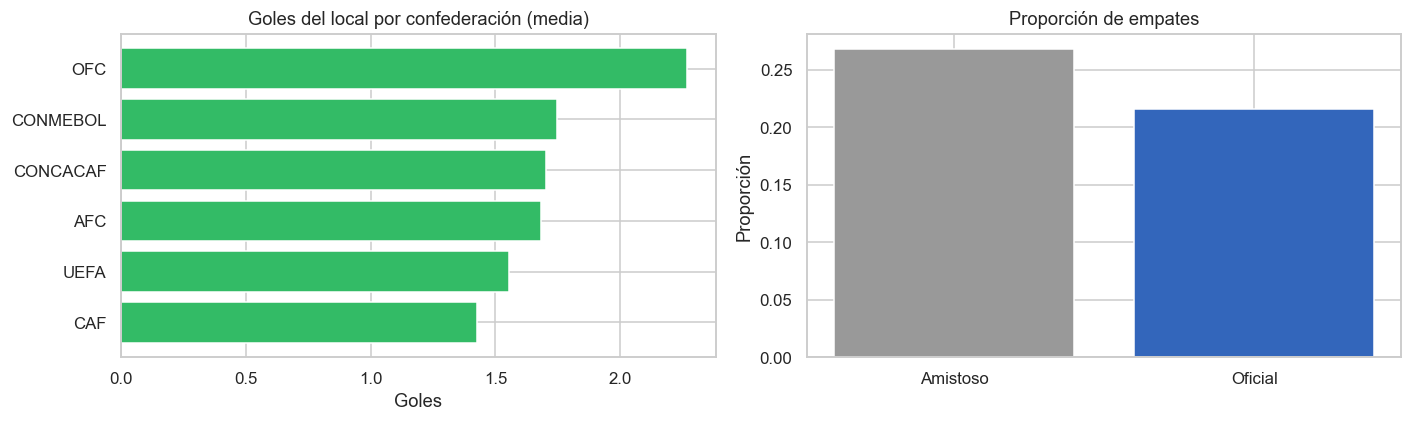

Empates  amistoso: 26.8 % | oficial: 21.6 %


In [19]:
# Mapa equipo -> confederación, tomado de su registro de ranking más reciente.
conf_map = (ranking.sort_values("rank_date")
                   .drop_duplicates("country_full", keep="last")
                   .set_index("country_full")["confederation"])
data_clean["home_conf"] = data_clean["home_team_norm"].map(conf_map)

# --- 11.1 Goles del local por confederación ---------------------------------
goles_conf = (data_clean.dropna(subset=["home_conf"])
                        .groupby("home_conf")["home_score"]
                        .agg(["mean", "count"])
                        .sort_values("mean", ascending=False))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(goles_conf.index, goles_conf["mean"], color="#3b6")
ax[0].set_title("Goles del local por confederación (media)")
ax[0].invert_yaxis(); ax[0].set_xlabel("Goles")

# --- 11.2 Empates: oficiales vs amistosos -----------------------------------
emp = (data_clean.assign(empate=data_clean["outcome"].eq("D"))
                 .groupby("is_official")["empate"].mean())
ax[1].bar(["Amistoso", "Oficial"], emp.values, color=["#999", "#36b"])
ax[1].set_title("Proporción de empates")
ax[1].set_ylabel("Proporción")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2c_confederaciones.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Empates  amistoso:", f"{emp.get(False,np.nan)*100:.1f} %",
      "| oficial:", f"{emp.get(True,np.nan)*100:.1f} %")

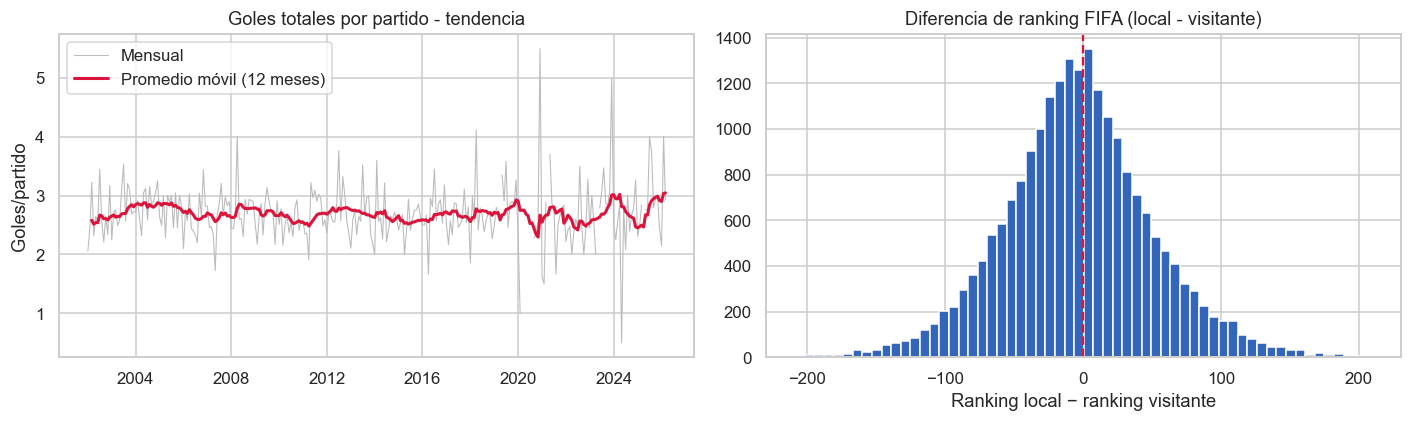

Diferencia de ranking - mediana: -4 | rango: [-209, 210]


In [20]:
# --- 11.3 Tendencia de goles en el tiempo (promedio móvil) ------------------
serie = (data_clean.assign(tot=lambda d: d["home_score"] + d["away_score"])
                   .set_index("date")["tot"]
                   .resample("MS").mean())
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(serie.index, serie.values, color="#bbb", lw=.7, label="Mensual")
ax[0].plot(serie.index, serie.rolling(12, min_periods=3).mean(),
           color="crimson", lw=2, label="Promedio móvil (12 meses)")
ax[0].set_title("Goles totales por partido - tendencia")
ax[0].set_ylabel("Goles/partido"); ax[0].legend()

# --- 11.4 Distribución de la diferencia de ranking local - visitante --------
diff = (data_clean["home_fifa_rank"] - data_clean["away_fifa_rank"]).dropna()
ax[1].hist(diff, bins=60, color="#36b", edgecolor="white")
ax[1].axvline(0, color="crimson", ls="--")
ax[1].set_title("Diferencia de ranking FIFA (local - visitante)")
ax[1].set_xlabel("Ranking local − ranking visitante")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2d_tendencia.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Diferencia de ranking - mediana:", f"{diff.median():.0f}",
      "| rango:", f"[{diff.min():.0f}, {diff.max():.0f}]")

**Lecturas rápidas:**

- *Goles por confederación:* perfiles ofensivos distintos por región - argumento para
  incluir `confederation` como feature.
- *Empates oficiales vs amistosos:* los partidos oficiales suelen empatar algo más
  (más en juego, planteamientos cerrados); refuerza el valor de `is_official`.
- *Tendencia de goles:* el promedio móvil revela si el fútbol de selecciones se ha
  vuelto más o menos goleador en la ventana - relevante para la ponderación temporal
  de Dixon-Coles.
- *Diferencia de ranking:* mediana cercana a 0 (los emparejamientos no están sesgados)
  con colas largas; será una de las features más predictivas.

---
## 12. Guardado del entregable y reporte

In [21]:
ruta = OUT_DIR / "data_clean.csv"
data_clean.drop(columns=["home_conf"]).to_csv(ruta, index=False)
print(f"Guardado: {ruta.resolve()}  ({data_clean.shape[0]:,} filas)")

Guardado: C:\Users\carba\OneDrive\Documents\AA UVG\Año 4, Ciclo 1\Modelos cuantitativos de información\Proyecto final\scripts\resultados\data_clean.csv  (23,086 filas)


In [22]:
from IPython.display import Markdown

n_part = len(data_clean)
n_years = data_clean["date"].dt.year.nunique()
a_min, a_max = data_clean["date"].dt.year.min(), data_clean["date"].dt.year.max()
n_eq = pd.unique(pd.concat([data_clean["home_team_norm"],
                            data_clean["away_team_norm"]])).size
cob = data_clean[["home_fifa_rank", "away_fifa_rank"]].notna().all(axis=1).mean()
n_pen = data_clean["winner_by_shootout"].notna().sum()

reporte = f'''
### Reporte de la Fase 1 - Datos

**Datos:** {n_part:,} partidos · {n_years} años ({a_min}-{a_max}) · {n_eq} equipos ·
{cob*100:.0f} % de cobertura de ranking FIFA en ambos lados.

- Ventana temporal: **desde {WINDOW_START}** (justificada por el esquema de validación
  temporal: garantiza historia suficiente para el primer pliegue, Mundial 2010).
- `is_official`: oficial = torneo ≠ *Friendly*. {data_clean['is_official'].mean()*100:.0f} %
  de los partidos son oficiales.
- QC del ranking extendido: empalme de mediados de 2024 **sin anomalías** (continuidad,
  escala de puntos y padrón estables; sin duplicados).
- Unión sin fuga de datos vía `merge_asof` (ranking previo al partido). El ~7 % sin
  ranking corresponde solo a territorios no miembros de la FIFA.
- {n_pen} partidos decididos por penales identificados en `winner_by_shootout`
  (para verificación, sin alterar el marcador reglamentario).

**Entregable:** `data_clean.csv` - listo para la Fase 2 (ingeniería de variables).
'''
Markdown(reporte)


### Reporte de la Fase 1 - Datos

**Datos:** 23,086 partidos · 25 años (2002-2026) · 318 equipos ·
93 % de cobertura de ranking FIFA en ambos lados.

- Ventana temporal: **desde 2002** (justificada por el esquema de validación
  temporal: garantiza historia suficiente para el primer pliegue, Mundial 2010).
- `is_official`: oficial = torneo ≠ *Friendly*. 67 %
  de los partidos son oficiales.
- QC del ranking extendido: empalme de mediados de 2024 **sin anomalías** (continuidad,
  escala de puntos y padrón estables; sin duplicados).
- Unión sin fuga de datos vía `merge_asof` (ranking previo al partido). El ~7 % sin
  ranking corresponde solo a territorios no miembros de la FIFA.
- 378 partidos decididos por penales identificados en `winner_by_shootout`
  (para verificación, sin alterar el marcador reglamentario).

**Entregable:** `data_clean.csv` - listo para la Fase 2 (ingeniería de variables).
